# 01 · 미분으로 학습시키기

**이번 질문:** 출력의 오차를 알 때, 가중치와 편향을 어느 방향으로 얼마나 바꾸어야 할까요?

[00번](00_math_to_numpy.ipynb)에서는 값이 주어진 $w, b$로 $Z=XW+b$를 계산했습니다.
이번에는 그 값을 **데이터에 맞게 스스로 정하는 과정**, 곧 학습을 만듭니다.
순서는 **목표를 손실로 표현하기 → 미분 → 역전파 → 파라미터 갱신 → 반복**이고, 한 문제에서 전부 연결합니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 손실은 "예측 − 정답"을 제곱해 평균낸 숫자 하나입니다. 코드로는 `0.5 * mean((Z - Y) ** 2)`.
2. 기울기는 파라미터와 같은 모양의 배열이고, 역전파 세 줄로 나옵니다. `dZ = (Z - Y) / (N*K)`, `dW = X.T @ dZ`, `db = dZ.sum(axis=0)`.
3. 갱신은 기울기의 반대 방향으로 조금 움직이는 것입니다. `W -= 학습률 * dW`. 반복하면 손실이 줄고, 기울기는 수치미분으로 검산합니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/gradient_plots.py)


In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path

project_root = next(                                   # 현재 폴더부터 위로 올라가며
    p for p in (Path.cwd(), *Path.cwd().parents)       # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
    if (p / "src" / "utils" / "plotting.py").is_file()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy와 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
import numpy as np
from src.utils import setup_plots
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· 준비 완료")

# 3) 수치미분 검사기(5절), 데이터 로더, 이 노트북의 그림 함수(src/utils/gradient_plots.py), 연습 검사 도우미
from src import check_function, rel_error
from src.utils import plot_gradcheck
from src.data.mnist import load_mnist, load_examples
from src.utils.gradient_plots import (
    plot_loss_from_residuals, plot_tangent, plot_gradient_image, plot_update_step,
    plot_training_images, plot_descent_landscape,
    plot_derivative, plot_difference_errors, plot_loss_surface,
    plot_fit_snapshots, plot_learning_curves,
)
from src.utils import run_check

NumPy 2.3.5 · 준비 완료


### 📎 이 노트북의 예시 두 가지: 과일 데이터와 MNIST

> **용어**
>
> - **데이터셋(dataset)**: 입력과 정답의 쌍을 모아 둔 것. 학습은 이 쌍들에 맞게 파라미터를 정하는 일입니다.
> - **잡음(noise)**: 정답에 섞인 측정 오차. 잡음이 있으면 어떤 직선도 모든 점을 정확히 지나지 못합니다.

**과일 데이터.** 과일 40개의 붉기 $x$(평균을 0으로 맞춘 값)와 당도 $y$를 쟀다고 하겠습니다.
실제로는 $y = 2x + 0.7$에 잡음을 더해 만듭니다. 붉기로 당도를 맞히는 직선 $\hat y = xw + b$를 데이터에서 찾는 것이 이 노트북의 문제입니다.
정답 규칙(2와 0.7)을 알고 만들었으니, 학습이 그 값에 가까워지는지 확인할 수 있습니다.

**MNIST.** 00번의 손글씨 숫자를 다시 씁니다. 이번에는 "이 이미지가 7이면 1, 아니면 0"을 맞히는 점수 $z = x\cdot w + b$를 학습합니다.
가중치 $w$가 784개라 28×28 이미지로 볼 수 있고, **기울기와 갱신도 이미지로 보입니다.** 그림에는 00번과 같은 고정 예시 10장을 씁니다.
시작은 "아무 정보가 없는 상태", 곧 $w=0$이고 모든 이미지에 같은 점수 $b=0.5$를 주는 상태입니다.
학습에는 학습 집합 앞 5,000장을 씁니다. 아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `np.linspace(-2.0, 2.0, 40)[:, None]`: −2부터 2까지 같은 간격의 숫자 40개 `(40,)`을 만든 뒤, `[:, None]`으로 길이 1인 축을 붙여 `(40, 1)` 열벡터로 세웁니다. 00번의 `X @ W + b`가 그대로 통하도록 "샘플 × 특성" 모양을 맞추는 것입니다.
> - `rng_data.normal(0.0, 0.15, size=...)`: 평균 0, 표준편차 0.15인 가우스 잡음을 그 모양만큼 뽑습니다. 시드를 고정한 `rng_data`라 실행마다 같은 값입니다.
> - `(mnist_labels == 7).astype(float)`: 비교 결과 True/False 배열을 1.0/0.0 실수로 바꿉니다.
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.

In [2]:
rng_data = np.random.default_rng(12)                                           # 시드를 고정한 난수 생성기: 실행할 때마다 같은 잡음
X_train = np.linspace(-2.0, 2.0, 40)[:, None]                                  # (40, 1): 과일 40개의 붉기. 행 하나가 과일 하나
Y_train = 2.0 * X_train + 0.7 + rng_data.normal(0.0, 0.15, size=X_train.shape)  # (40, 1): 당도 = 2·붉기 + 0.7 + 잡음(표준편차 0.15)
W_start, b_start = np.array([[-1.5]]), np.array([-1.0])                        # (1, 1), (1,): 일부러 정답(2, 0.7)의 반대 방향에서 시작

mnist_examples, mnist_labels = load_examples(download=True)                    # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_Xe = mnist_examples.reshape(10, -1)                                      # (10, 784): 한 장을 한 행으로 펼침 (00번 6절)
mnist_Te = (mnist_labels == 7).astype(float)[:, None]                          # (10, 1): 7이면 1.0, 아니면 0.0. 그림·손계산용 정답
mnist_X_all, mnist_y_all, _, _ = load_mnist()                                  # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mnist_X, mnist_T = mnist_X_all[:5000], (mnist_y_all[:5000] == 7).astype(float)[:, None]   # (5000, 784), (5000, 1): 학습용 앞 5,000장
print("과일", X_train.shape, Y_train.shape, "· MNIST 예시", mnist_Xe.shape, "· 학습용", mnist_X.shape)

과일 (40, 1) (40, 1) · MNIST 예시 (10, 784) · 학습용 (5000, 784)


## 🔑 1. 원하는 결과를 손실로 만듭니다

**이 절에서 가져갈 것:** "얼마나 틀렸는가"를 숫자 하나로 만든 것이 손실입니다. 예측에서 정답을 빼고, 제곱해서, 평균냅니다. 코드로는 `0.5 * mean((Z - Y) ** 2)`.

지금 직선은 $w=-1.5$, $b=-1$이라 과일의 당도를 거의 반대로 예측합니다. 이 직선을 고치려면 먼저 "얼마나 틀렸는지"를 숫자 하나로 재야 합니다.
그래야 두 직선 중 어느 쪽이 나은지 비교할 수 있고, 다음 절에서 그 숫자가 줄어드는 방향을 계산할 수 있습니다.

> **용어**
>
> - **회귀(regression)**: 입력에서 숫자 하나를 맞히는 문제. 붉기에서 당도를 맞히는 것.
> - **예측값** $\hat y$: 모델이 내놓은 값 $xw+b$. 모자는 "모델의 답"이라는 표시이고, $y$는 관측한 정답입니다.
> - **잔차(residual)** $r=\hat y-y$: 예측에서 정답을 뺀 값. 양수면 높게, 음수면 낮게 예측한 것.
> - **손실(loss)** $J$: 모든 잔차를 숫자 하나로 요약한 것. 작을수록 좋습니다.

$$J=\frac1{2M}\sum_{j=1}^{M}(\hat y_j-y_j)^2.$$

잔차를 그대로 더하면 양수와 음수가 상쇄되므로 **제곱**합니다. 제곱은 큰 잔차에 더 큰 값을 주고, 미분이 매끄럽습니다.
그다음 개수 $M$으로 나누어 **평균**을 내면 데이터가 40개든 4,000개든 같은 잣대가 됩니다.
$M$은 평균에 들어간 스칼라 출력값의 총 개수이고, 예측이 `(N, K)`이면 $M=NK$입니다.

📎 $1/2$는 뒤에서 제곱을 미분할 때 나오는 2와 약분하려고 붙인 것입니다. 최솟값의 위치는 바뀌지 않습니다.
이 정의를 **MSE(mean squared error, 평균제곱오차)**의 절반이라고 부르겠습니다. 02번에서는 "관측에 가우스 잡음이 있다"는 가정에서 같은 식을 다시 유도합니다.


In [3]:
# 쓰는 것: X_train, Y_train, W_start, b_start (📎 데이터 셀)
line_x = np.linspace(-2.2, 2.2, 100)[:, None]                # (100, 1): 직선을 그릴 붉기 좌표
line_y = line_x @ W_start + b_start                          # (100, 1): 지금 직선의 예측 ŷ = x·w + b
residual_start = X_train @ W_start + b_start - Y_train      # (40, 1): 과일마다 예측 − 정답 (잔차 r)
loss_start = 0.5 * np.mean(residual_start ** 2)             # 숫자 하나: 잔차 제곱의 평균에 1/2. 위 식의 J
print(f"잔차 범위 {residual_start.min():.2f} … {residual_start.max():.2f} · 손실 {loss_start:.3f}")

잔차 범위 -8.97 … 5.30 · 손실 9.962


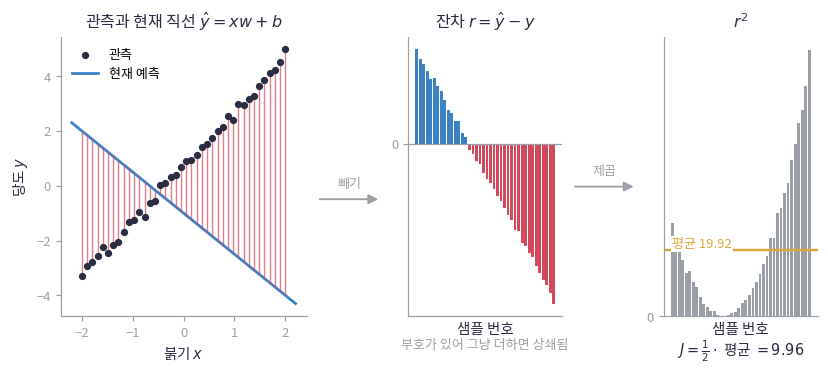

In [4]:
plot_loss_from_residuals(X_train.ravel(), Y_train.ravel(), line_x.ravel(), line_y.ravel(), residual_start, loss_start)

🔍 **확인** · 왼쪽의 빨간 세로선이 잔차입니다. 직선이 반대로 기울어 왼쪽 과일은 높게, 오른쪽 과일은 낮게 예측했습니다.
가운데처럼 잔차는 부호가 있어 그냥 더하면 상쇄되고, 오른쪽처럼 제곱하면 모두 양수가 되어 큰 잔차가 더 크게 보입니다.
제곱의 평균에 $\tfrac12$를 곱한 값이 이 직선의 손실 $J$입니다. 이제 이 숫자 하나를 줄이는 것이 목표입니다.

In [5]:
def mse_forward(prediction, target):
    """절반 MSE 손실: J = (1/2M) Σ (prediction − target)², M은 원소 수.
    prediction, target: 같은 모양 (N, K) → (J: 숫자 하나, residual: (N, K) 잔차). 잔차는 4절 backward에 다시 씁니다."""
    if prediction.shape != target.shape or prediction.size == 0:
        raise ValueError("prediction과 target은 같은 모양의 비어 있지 않은 배열로 둡니다.")
    residual = prediction - target          # (N, K): 예측 − 정답
    return 0.5 * np.mean(residual ** 2), residual

In [6]:
prediction_example = np.array([[0.0], [2.0], [4.0]])        # (3, 1): 예측 3개
target_example = np.array([[1.0], [1.0], [3.0]])            # (3, 1): 정답 3개
loss_example, residual_example = mse_forward(prediction_example, target_example)
np.testing.assert_array_equal(residual_example, [[-1.0], [1.0], [1.0]])   # 검산: 잔차 = 예측 − 정답
np.testing.assert_allclose(loss_example, 0.5)                             # 검산: 손계산 0.5·(1 + 1 + 1)/3 = 0.5
print("잔차", residual_example.ravel(), "· 손실", loss_example)

잔차 [-1.  1.  1.] · 손실 0.5


🔍 **확인** · 손실은 모델 전체를 평가하는 **스칼라 하나**입니다. 그 값이 작아지는 방향으로 파라미터를 움직이는 것이 여기서의 학습 목표입니다.
`assert_allclose`는 00번처럼 손계산 값과의 검산입니다.

## 🔑 2. 미분은 작은 변화에 대한 반응입니다

**이 절에서 가져갈 것:** 미분은 "입력을 아주 조금 바꾸면 출력이 얼마나 변하는가"의 비율입니다. 이 비율을 알면 손실을 줄이는 방향을 알 수 있습니다.

손실 $J$는 $w$와 $b$에 따라 달라지는 함수입니다. $w$를 조금 키웠을 때 $J$가 커지는지 작아지는지, 얼마나 변하는지를 알아야 어느 쪽으로 움직일지 정할 수 있습니다.
먼저 변수가 하나인 함수 $f(w)$에서 이 비율을 정의하겠습니다.

> **용어**
>
> - **평균 변화율**: 입력을 $h$만큼 바꿨을 때 출력 변화를 $h$로 나눈 것. $\big(f(w+h)-f(w)\big)/h$.
> - **도함수(derivative)** $f'(w)$: $h$를 0에 가깝게 보냈을 때 평균 변화율이 다가가는 값. "미분한다"는 이 값을 구하는 것입니다.
> - **접선(tangent)**: 그 점에서 함수와 같은 기울기를 가진 직선. 도함수가 접선의 기울기입니다.

$$f'(w)=\lim_{h\to0}\frac{f(w+h)-f(w)}h,\qquad f(w+\Delta w)\approx f(w)+f'(w)\,\Delta w.$$

오른쪽 식이 미분을 쓰는 이유입니다. 작은 $\Delta w$에 대해 **함수값의 변화를 곱셈 하나로 예측**할 수 있습니다.

예를 들어 $f(w)=w^3$이면

$$\frac{(w+h)^3-w^3}{h}=3w^2+3wh+h^2\quad\longrightarrow\quad f'(w)=3w^2.$$

$w=1$에서 도함수는 3입니다. 아래에서 함수, 그 점의 접선, 폭 0.3인 두 점 사이의 평균 변화율을 함께 봅니다.


In [7]:
w0, h = 1.0, 0.3                                            # 접점 w = 1, 두 점 사이의 폭 h
grid = np.linspace(0.3, 1.7, 150)                           # (150,): 곡선 f(w) = w³을 그릴 w 좌표
slope_at_w0 = 3 * w0 ** 2                                   # 도함수 f'(1) = 3·1² = 3. 접선의 기울기
secant_w = np.array([w0, w0 + h])                           # (2,): 평균 변화율을 잴 두 점의 w
secant_f = secant_w ** 3                                    # (2,): 그 두 점의 함수값
print("접선 기울기", slope_at_w0, "· 폭 0.3의 평균 변화율", (secant_f[1] - secant_f[0]) / h)

접선 기울기 3.0 · 폭 0.3의 평균 변화율 3.99


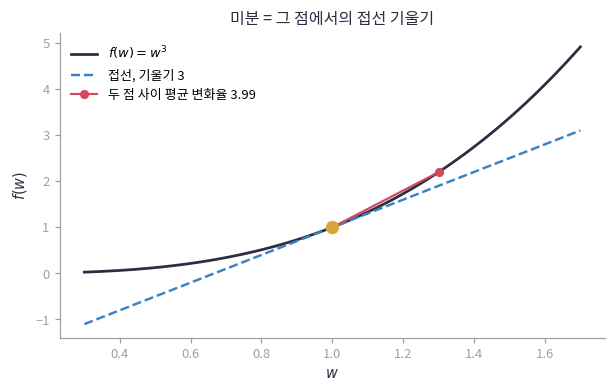

In [8]:
plot_tangent(grid, grid ** 3, w0, w0 ** 3, slope_at_w0, secant_w, secant_f)

🔍 **확인** · 빨간 두 점 사이의 평균 변화율(3.99)은 접선 기울기(3)보다 큽니다. 두 점의 간격이 작아질수록 평균 변화율은 접선 기울기에 가까워집니다.
접선은 그 점 **근처**의 변화만 설명합니다. 파라미터를 크게 움직이면 실제 함수의 휨도 영향을 줍니다. 이것이 뒤에서 학습률을 작게 잡는 이유입니다.

In [9]:
def cubic(w):
    """예시 함수 f(w) = w³. w: 숫자 또는 배열 → 같은 모양."""
    return w ** 3


def cubic_derivative(w):
    """손으로 유도한 도함수 f'(w) = 3w². w: 숫자 또는 배열 → 같은 모양."""
    return 3 * w ** 2

In [10]:
np.testing.assert_allclose(cubic_derivative(w0), slope_at_w0)   # 검산: 함수로 만든 도함수 = 위 셀의 f'(1) = 3
np.testing.assert_allclose(cubic(secant_w), secant_f)           # 검산: 함수값 = 위 셀의 두 점
print("도함수", cubic_derivative(w0), "· 폭 0.3의 평균 변화율", (cubic(w0 + h) - cubic(w0)) / h)

도함수 3.0 · 폭 0.3의 평균 변화율 3.99


## 🔍 3. 수치미분으로 도함수를 검산합니다

> **용어**
>
> - **수치미분(numerical differentiation)**: 도함수를 식으로 유도하지 않고, 실제로 입력을 조금 바꿔 함수값 차이로 근사하는 것.
> - **전진차분·중심차분**: 앞으로만 $\epsilon$ 움직여 비교하면 전진차분, 좌우로 $\epsilon$씩 움직여 비교하면 중심차분입니다.

앞의 평균 변화율 식을 그대로 계산한 것이 **전진차분**입니다. 좌우를 함께 사용하는 **중심차분**은 다음과 같습니다.

$$f'(w)\approx\frac{f(w+\epsilon)-f(w-\epsilon)}{2\epsilon}.$$

3차식에서 중심차분을 직접 전개하면 $3w^2+\epsilon^2$입니다.
전진차분의 $3w\epsilon$ 항이 사라지므로, 반올림 오차가 작을 때 더 정확합니다.
하지만 매우 작은 $\epsilon$에서는 거의 같은 두 수를 빼는 부동소수점 오차가 영향을 줍니다.
이 노트북에서 유도하는 모든 기울기는 이 중심차분과 대조해 검산합니다.

> **코드**
>
> - `np.logspace(-1, -12, 12)`: 10⁻¹부터 10⁻¹²까지 로그 눈금으로 같은 간격인 숫자 12개. 자릿수를 하나씩 줄이며 ε을 시험합니다.
> - `[식 for e in epsilons]`(컴프리헨션): 목록의 원소마다 식을 계산해 새 목록으로 모읍니다. 반복문 하나를 한 줄에 쓴 것입니다.
> - `zip(a, b)`: 두 목록을 나란히 짝지어 (a[0], b[0]), (a[1], b[1]), … 순서로 돕니다.

In [11]:
def central_difference(function, value, epsilon=1e-6):
    """중심차분: (f(w+ε) − f(w−ε)) / 2ε. function: 숫자 → 숫자인 함수, value: 미분할 위치 w → 도함수의 근사값 하나."""
    return (function(value + epsilon) - function(value - epsilon)) / (2 * epsilon)

In [12]:
# 쓰는 것: w0 (2절의 접점 w = 1) · cubic, cubic_derivative (2절)
epsilons = np.logspace(-1, -12, 12)                                                  # (12,): ε = 0.1, 0.01, …, 1e−12
forward_estimates = np.array([(cubic(w0 + e) - cubic(w0)) / e for e in epsilons])    # (12,): 전진차분 (f(w+ε) − f(w)) / ε
central_estimates = np.array([central_difference(cubic, w0, e) for e in epsilons])   # (12,): 중심차분
forward_errors = np.abs(forward_estimates - cubic_derivative(w0))                    # (12,): 참값 3과의 차이
central_errors = np.abs(central_estimates - cubic_derivative(w0))
np.testing.assert_allclose(central_difference(cubic, w0), 3.0, rtol=1e-8)            # 검산: 기본 ε = 1e−6에서 중심차분 = 3
for e, estimate in zip(epsilons, central_estimates):
    print(f"epsilon={e:.0e} · 중심차분 {estimate:.10f}")

epsilon=1e-01 · 중심차분 3.0100000000
epsilon=1e-02 · 중심차분 3.0001000000
epsilon=1e-03 · 중심차분 3.0000010000
epsilon=1e-04 · 중심차분 3.0000000100
epsilon=1e-05 · 중심차분 3.0000000001
epsilon=1e-06 · 중심차분 2.9999999999
epsilon=1e-07 · 중심차분 3.0000000001
epsilon=1e-08 · 중심차분 2.9999999929
epsilon=1e-09 · 중심차분 3.0000000817
epsilon=1e-10 · 중심차분 3.0000002482
epsilon=1e-11 · 중심차분 3.0000002482
epsilon=1e-12 · 중심차분 3.0001001683


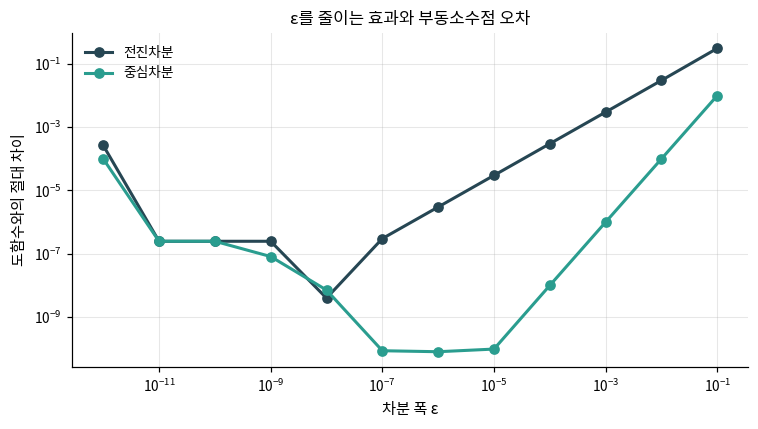

In [13]:
plot_difference_errors(epsilons, forward_errors, central_errors)

📎 **참고** · 수치미분은 유도한 기울기를 점검하는 별도의 계산 방법입니다.
파라미터가 $P$개이면 중심차분에 대략 $2P$번의 함수 평가가 필요하므로, 큰 모델의 매 학습 스텝에는 다음 절에서 유도할 역전파를 사용합니다.

## 🔑 4. 연쇄법칙으로 손실에서 입력까지 거슬러 갑니다

**이 절에서 가져갈 것:** 손실은 여러 계산을 거쳐 나오므로, 각 단계의 변화율을 **곱하면** 파라미터에 대한 변화율이 됩니다. 결과는 세 줄입니다. `dZ = (Z - Y) / (N*K)`, `dW = X.T @ dZ`, `db = dZ.sum(axis=0)`.

$w$를 조금 바꾸면 예측 $z$가 바뀌고, 잔차 $r$이 바뀌고, 손실 $J$가 바뀝니다. 먼저 스칼라 하나로 이 사슬을 보겠습니다.

$$w\ \longrightarrow\ z=xw+b\ \longrightarrow\ r=z-y\ \longrightarrow\ J=\tfrac12r^2.$$

> **용어**
>
> - **연쇄법칙(chain rule)**: 사슬처럼 이어진 계산에서 전체 변화율은 각 화살표의 변화율을 곱한 것이라는 규칙.
> - **편미분** $\partial$: 변수가 여러 개일 때 다른 변수는 고정하고 하나만 바꾸는 미분. $\partial J/\partial w$는 "$b$는 그대로 두고 $w$만 조금 바꿨을 때 $J$의 변화율".
> - **기울기(gradient)**: 모든 파라미터에 대한 편미분을 파라미터와 같은 모양으로 모은 배열. $W$가 `(D, K)`이면 기울기도 `(D, K)`.
> - **역전파(backpropagation)**: 손실에서 출발해 사슬을 **역순으로** 따라가며 각 파라미터의 기울기를 계산하는 절차.

$$\frac{\partial J}{\partial w}
=\frac{\partial J}{\partial r}\frac{\partial r}{\partial z}\frac{\partial z}{\partial w}
=r\cdot1\cdot x.$$

배치와 출력이 여러 개이면 평균에 포함된 모든 값의 개수로 나눕니다.

$$dZ_{nk}:=\frac{\partial J}{\partial Z_{nk}}=\frac{Z_{nk}-Y_{nk}}{NK}.$$

여기서 `dZ`는 미분 기호 자체가 아니라, 각 원소에 대한 편미분을 모은 배열의 이름입니다.

선형 계산 $Z_{nk}=\sum_d X_{nd}W_{dk}+b_k$에서 $W_{dk}$ 하나는 모든 샘플에 쓰입니다.
각 사용처의 기여를 더하면 다음 식이 나옵니다.

$$dW_{dk}=\sum_n X_{nd}\,dZ_{nk},\qquad
 db_k=\sum_n dZ_{nk},\qquad
 dX_{nd}=\sum_k dZ_{nk}\,W_{dk}.$$

| 미분 배열 | 모양 | 배열 연산 |
|---|---|---|
| $dZ$ | `(N, K)` | `(Z - Y) / (N * K)` |
| $dW$ | `(D, K)` | `X.T @ dZ` |
| $db$ | `(K,)` | `dZ.sum(axis=0)` |
| $dX$ | `(N, D)` | `dZ @ W.T` |

$X^\top$는 샘플 축 $n$을 곱하고 더하기 위한 배치입니다. 00번의 인덱스 식과 행렬곱의 대응을 다시 사용한 것입니다.
아래에서는 이 세 줄을 MNIST에 적용해 **기울기가 어떻게 생겼는지** 봅니다.

> **코드**
>
> - `R_e.size`: 배열의 원소 수. 예측이 `(N, K)`이면 `N * K`이고, 이것이 평균의 분모 $M$입니다.
> - `mnist_Xe[is_seven]`(불리언 인덱싱): `is_seven`이 True인 행만 고릅니다. `is_seven` 앞에 부정 연산자(물결표 기호)를 붙이면 False인 행만 고릅니다.

In [14]:
# 쓰는 것: mnist_Xe, mnist_Te (📎 데이터 셀의 예시 10장과 "7이면 1" 정답)
w_zero, b_half = np.zeros((784, 1)), np.array([0.5])    # (784, 1), (1,): 시작은 w = 0, b = 0.5 (모든 이미지에 같은 점수)
Z_e = mnist_Xe @ w_zero + b_half                    # (10, 1) 점수: 전부 0.5
R_e = Z_e - mnist_Te                                # (10, 1) 잔차: 7은 −0.5, 나머지는 +0.5
dZ_e = R_e / R_e.size                               # (10, 1): dZ = R / (N·K), 여기서는 잔차를 10으로 나눈 것
dW_e = mnist_Xe.T @ dZ_e                            # (784, 1): dW = Xᵀ dZ. 각 이미지 × 그 잔차를 모두 더함
db_e = dZ_e.sum(axis=0)                             # (1,): db = 샘플 축의 합
assert dW_e.shape == w_zero.shape, "기울기 dW는 파라미터 w와 같은 모양이어야 합니다"
print("잔차", R_e.ravel().round(2))
is_seven = mnist_Te.ravel() == 1                    # (10,): 7인 자리만 True
dW_from_7 = mnist_Xe[is_seven].T @ dZ_e[is_seven]           # (784, 1): 7 한 장의 기여
dW_from_rest = mnist_Xe[~is_seven].T @ dZ_e[~is_seven]      # (784, 1): 나머지 아홉 장의 기여
np.testing.assert_allclose(dW_from_7 + dW_from_rest, dW_e)  # 검산: 두 기여의 합 = 전체 기울기 (Σ_n 을 둘로 나눈 것)

잔차 [ 0.5  0.5  0.5  0.5  0.5  0.5  0.5 -0.5  0.5  0.5]


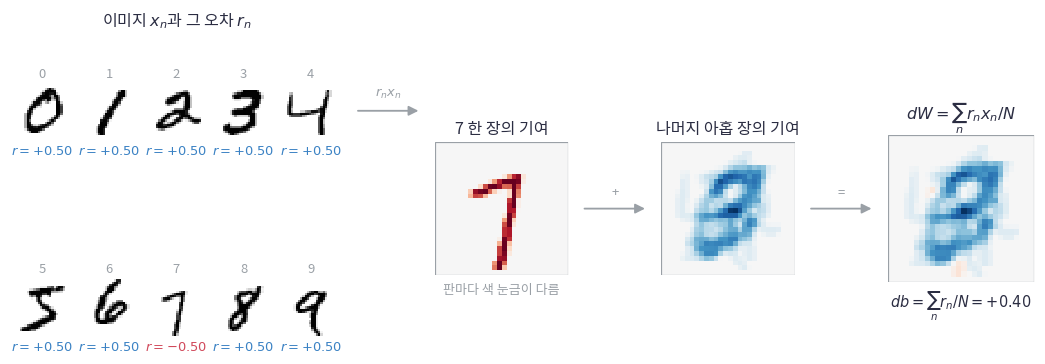

In [15]:
plot_gradient_image(mnist_examples, R_e, mnist_labels,
                    [dW_from_7.reshape(28, 28), dW_from_rest.reshape(28, 28)], ["7 한 장의 기여", "나머지 아홉 장의 기여"],
                    dW_e.reshape(28, 28), float(db_e[0]))

🔍 **확인** · 맨 오른쪽이 기울기 $dW$를 28×28로 접은 것입니다. `X.T @ dZ`는 "각 이미지에 그 이미지의 잔차를 곱해 모두 더한다"는 뜻이라, 결과도 이미지 모양입니다.
가운데 두 판은 그 합을 둘로 나눈 것입니다. 7은 정답 1보다 낮게 예측되어 잔차가 음수이므로 7의 획 자리가 빨강(음수)이고,
나머지 아홉 장은 정답 0보다 높게 예측되어 획 자리가 파랑(양수)입니다. 합에서는 아홉 장이 겹친 파랑이 우세하지만 7의 빨강도 그 안에 들어 있습니다.
빨간 자리의 $w$를 **키우고** 파란 자리를 **줄이면** 손실이 줄어듭니다. 기울기가 곧 "어느 화소를 어느 쪽으로 고치라"는 지시서입니다.
편향의 기울기 $db$는 잔차의 평균이라 양수입니다. 점수를 전체적으로 낮추라는 뜻입니다.

In [16]:
def affine_forward(X, W, b):
    """선형층 forward: Z = X @ W + b (00번 4절의 affine).
    X: (N, D), W: (D, K), b: (K,) → (Z: (N, K), cache: backward에 필요한 (X, W))."""
    Z = X @ W + b
    return Z, (X, W)


def affine_backward(dZ, cache):
    """선형층 backward: 상류 기울기 dZ에서 입력·가중치·편향의 기울기. 위 표의 세 줄입니다.
    dZ: (N, K), cache: (X (N, D), W (D, K)) → (dX: (N, D), dW: (D, K), db: (K,))."""
    X, W = cache
    dX = dZ @ W.T                # (N, D): dX_nd = Σ_k dZ_nk W_dk
    dW = X.T @ dZ                # (D, K): dW_dk = Σ_n X_nd dZ_nk. 샘플 축 n을 곱해 더함
    db = dZ.sum(axis=0)          # (K,): db_k = Σ_n dZ_nk
    return dX, dW, db


def mse_backward(residual):
    """절반 MSE의 예측에 대한 미분: dZ = residual / M, M = 원소 수. residual: (N, K) → dZ: (N, K)."""
    return residual / residual.size

In [17]:
# 쓰는 것: mse_forward (1절)
X_small = np.array([[-1.0], [0.0], [1.0]])              # (3, 1): 샘플 3개, 특성 1개
Y_small = np.array([[-1.0], [1.0], [3.0]])              # (3, 1): 정답
W_small, b_small = np.array([[0.0]]), np.array([0.0])   # (1, 1), (1,): 0에서 시작
Z_small, affine_cache = affine_forward(X_small, W_small, b_small)      # 예측은 전부 0
J_small, residual = mse_forward(Z_small, Y_small)                      # 잔차 [1, −1, −3]에서 손실 (1 + 1 + 9)/(2·3)
dX_small, dW_small, db_small = affine_backward(mse_backward(residual), affine_cache)   # dZ = 잔차/3 을 뒤로 보냄
np.testing.assert_allclose(J_small, 11 / 6)             # 검산: 손실 = 11/6
np.testing.assert_allclose(dW_small, [[-4 / 3]])        # 검산: dW = Σ_n x_n·dZ_n = (−1·1 + 0·(−1) + 1·(−3))/3 = −4/3
np.testing.assert_allclose(db_small, [-1.0])            # 검산: db = Σ_n dZ_n = (1 − 1 − 3)/3 = −1
print("예측", Z_small.ravel(), "· 손실", J_small)
print("손계산과 비교: dW", dW_small.ravel(), "db", db_small)

예측 [0. 0. 0.] · 손실 1.8333333333333333
손계산과 비교: dW [-1.3333] db [-1.]


🔍 **확인** · 이 작은 예제에서 $W$와 $b$에 대한 기울기가 모두 음수입니다. 따라서 두 값을 조금 늘리면 손실이 줄어들 것으로 예상할 수 있습니다.

캐시에는 backward에 필요한 $X$와 $W$를 남겼습니다.
입력 $X$를 학습하지 않는 이 회귀 문제에서도 $dX$를 계산해 두면, 앞에 다른 계산을 이어 붙였을 때 전달할 수 있습니다.

## 🔍 5. 모든 기울기를 다른 계산으로 대조합니다

> **용어**
>
> - **상류 기울기(upstream gradient)**: 내 출력이 최종 손실에 미치는 변화율. backward 함수는 이 값을 받아 자기 입력의 기울기로 바꿉니다.
> - **상대오차**: 두 기울기의 차이를 크기로 나눈 것. $10^{-7}$ 아래면 같은 값으로 봅니다.

검산에는 작은 입력을 사용하되 **출력이 2개인 경우**도 넣습니다.
출력 개수가 늘었을 때 평균의 분모를 빠뜨리는 실수를 확인하기 위해서입니다.

`check_function`은 입력 배열의 각 원소를 좌우로 조금씩 바꾸어 중심차분을 계산합니다.
여기서는 손실을 $X$, $W$, $b$ 각각의 함수로 보고, 손으로 유도한 기울기와 대조합니다.

📎 아래 콜백의 `dout`은 **검사기가 forward의 출력으로 전달하는 상류 기울기**입니다.
이 forward는 스칼라 손실 $J$를 반환합니다. 검사기는 고정된 스칼라 $u$를 골라
$G=uJ$의 변화율을 중심차분으로 계산하고, `backward`에는 `dout=u`를 전달합니다.
연쇄법칙에 따라 $\partial G/\partial W=u\,\partial J/\partial W$이므로,
콜백도 이미 구한 기울기에 `dout`을 곱해야 같은 값을 비교할 수 있습니다.
앞의 `dZ`는 $\partial J/\partial Z$로 예측 배열과 같은 `(N, K)` 모양이었고, 여기의 `dout`은 $\partial G/\partial J$로 스칼라입니다.
검사기의 내부 구현은 [gradcheck.py](../../src/utils/gradcheck.py)의 `check_function`에서 볼 수 있습니다.

> **코드**
>
> - `dict(arguments)`: 사전의 복사본. 원본 `arguments`는 두고 복사본의 값 하나만 바꾸기 위해서입니다.
> - `loss_and_gradients(**current, Y=Y)`: 사전의 키를 인자 이름으로 삼아 펼쳐 넣습니다. `current = {"X": …, "W": …, "b": …}`이면 `loss_and_gradients(X=…, W=…, b=…, Y=Y)`와 같습니다.
> - `def forward(value, name=name)`: 반복문 안에서 함수를 만들 때, 반복 변수 `name`의 **그때 값**을 기본 인자로 붙잡아 둡니다. 이렇게 하지 않으면 세 함수가 모두 마지막 `name`을 보게 됩니다.

In [18]:
def loss_and_gradients(X, W, b, Y):
    """forward 두 단계(선형층 → 절반 MSE)와 backward 두 단계를 한 번에: J와 dX, dW, db.
    X: (N, D), W: (D, K), b: (K,), Y: (N, K) → (J: 숫자, {"X": dX, "W": dW, "b": db})."""
    # 쓰는 것: affine_forward, affine_backward, mse_backward (4절) · mse_forward (1절)
    Z, cache = affine_forward(X, W, b)
    loss, residual = mse_forward(Z, Y)
    dX, dW, db = affine_backward(mse_backward(residual), cache)
    return loss, {"X": dX, "W": dW, "b": db}


def check_affine_mse(arguments, Y):
    """X, W, b 각각에 대해 손으로 유도한 기울기를 중심차분과 대조합니다.
    arguments: {"X", "W", "b"} 사전, Y: (N, K) → {"dX", "dW", "db"}: 상대오차."""
    errors = {}
    for name in ("X", "W", "b"):
        def forward(value, name=name):
            """name 자리의 값만 value로 바꿨을 때의 손실 J. 검사기가 좌우로 흔들어 볼 함수."""
            current = dict(arguments)
            current[name] = value
            return np.array(loss_and_gradients(**current, Y=Y)[0])

        def backward(dout, value, name=name):
            """같은 자리에서 손으로 유도한 기울기에 상류 기울기 dout을 곱한 것 (연쇄법칙 ∂G/∂θ = u·∂J/∂θ)."""
            current = dict(arguments)
            current[name] = value
            return dout * loss_and_gradients(**current, Y=Y)[1][name]

        errors["d" + name] = check_function(
            forward, backward, arguments[name], name="d" + name, verbose=True,
        )
    return errors

In [19]:
rng = np.random.default_rng(7)
check_arguments = {
    "X": rng.normal(size=(4, 3)),      # (4, 3): 샘플 4개, 특성 3개의 무작위 입력
    "W": rng.normal(size=(3, 2)),      # (3, 2): 출력이 2개인 경우
    "b": rng.normal(size=(2,)),        # (2,)
}
check_Y = rng.normal(size=(4, 2))      # (4, 2): 무작위 정답
gradient_errors = check_affine_mse(check_arguments, check_Y)
assert max(gradient_errors.values()) < 1e-7, "세 기울기의 상대오차가 모두 1e−7 아래여야 합니다"

[gradcheck] dX
  ok   dx  rel_err = 1.512e-10
[gradcheck] dW
  ok   dx  rel_err = 1.713e-10
[gradcheck] db
  ok   dx  rel_err = 6.268e-11


<Axes: ylabel='상대오차'>

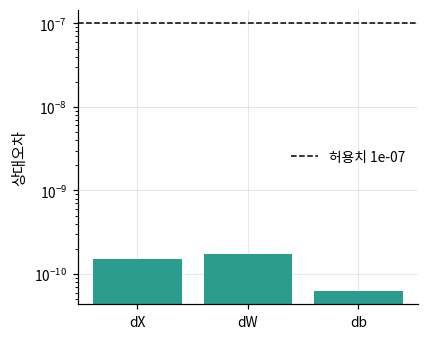

In [20]:
plot_gradcheck(gradient_errors)

### 🔍 평균을 두 번 내는 실수를 검산으로 찾습니다

상류의 `dZ`에는 손실의 평균이 이미 반영되어 있습니다.
여기서 `db = dZ.mean(axis=0)`으로 계산하면 샘플 수로 한 번 더 나누게 됩니다.
아래에서는 이 식만 바꾼 기울기를 검사해, 검산이 차이를 잡는지 확인합니다.

In [21]:
def wrong_bias_gradient(dout, bias_value):
    """일부러 틀린 db: dZ를 합하지 않고 평균내 샘플 수로 한 번 더 나눕니다. dout: 숫자, bias_value: (K,) → (K,)."""
    # 쓰는 것: check_arguments, check_Y (앞 셀) · affine_forward, mse_backward (4절) · mse_forward (1절)
    current = dict(check_arguments)
    current["b"] = bias_value
    Z, _ = affine_forward(**current)
    _, residual = mse_forward(Z, check_Y)
    return dout * mse_backward(residual).mean(axis=0)     # 맞는 식은 .sum(axis=0)


def bias_objective(bias_value):
    """b만 bias_value로 바꿨을 때의 손실 J. 검사기가 중심차분을 계산할 함수. bias_value: (K,) → 숫자 하나."""
    # 쓰는 것: check_arguments, check_Y (앞 셀) · loss_and_gradients (5절)
    return np.array(loss_and_gradients(check_arguments["X"], check_arguments["W"], bias_value, check_Y)[0])

In [22]:
wrong_error = check_function(bias_objective, wrong_bias_gradient, check_arguments["b"],
                             raise_on_fail=False, name="평균 중복", verbose=True)   # 틀려도 예외 대신 오차만 돌려받습니다
assert wrong_error > 1e-3, "평균을 두 번 낸 db는 상대오차가 커서 검산에 걸려야 합니다"
print("정상 db 오차", gradient_errors["db"], "· 평균을 두 번 낸 db 오차", wrong_error)

[gradcheck] 평균 중복
  FAIL dx  rel_err = 7.500e-01
정상 db 오차 6.268162498977536e-11 · 평균을 두 번 낸 db 오차 0.7500000000017653


## 🔑 6. 미분을 파라미터 갱신으로 연결합니다

**이 절에서 가져갈 것:** 기울기의 반대 방향으로 조금 움직이면 손실이 줄어듭니다. 코드로는 `W -= 학습률 * dW`.

기울기 $g=\partial J/\partial w$는 "$w$를 키우면 손실이 이만큼 변한다"는 뜻이었습니다. 손실을 **줄이려면** 반대 방향으로 가면 됩니다.

> **용어**
>
> - **학습률(learning rate)** $\eta$: 한 번에 얼마나 움직일지 정하는 양수. 기울기에 곱합니다.
> - **경사하강(gradient descent)**: 기울기의 반대 방향으로 조금씩 내려가는 갱신 규칙. "경사"가 기울기입니다.

$$w_{\mathrm{new}}=w-\eta g.$$

2절의 근사식에 $\Delta w=-\eta g$를 넣으면

$$\Delta J\approx g\Delta w=-\eta g^2\le0$$

가 됩니다. 여러 파라미터에서도 $\Delta J\approx-\eta\|\nabla J\|^2$입니다.
이 관계가 기울기의 반대 방향으로 움직이는 이유입니다. 다만 근사는 작은 스텝에서만 맞으므로, 큰 스텝의 결과는 실제 손실로 확인합니다.

역전파는 **기울기를 계산**하고, optimizer는 그 값을 사용해 **파라미터를 갱신**합니다. 04번에서 갱신 규칙을 여러 가지로 바꿉니다.
아래는 MNIST 가중치 이미지에서 이 한 스텝이 어떻게 보이는지입니다.


In [23]:
# 쓰는 것: w_zero, b_half, dW_e, db_e, R_e (4절 MNIST 기울기 셀) · mnist_Xe, mnist_Te (📎 데이터 셀)
eta = 0.02                                          # 학습률 η. 784차원에서는 작은 학습률이 필요합니다
w_new = w_zero - eta * dW_e                         # (784, 1): w − η·dW
b_new = b_half - eta * db_e                         # (1,): b − η·db
Z_after = mnist_Xe @ w_new + b_new                  # (10, 1): 갱신 뒤 점수
loss_before = 0.5 * np.mean(R_e ** 2)               # 갱신 전 손실 (잔차 R_e는 4절 것)
loss_after = 0.5 * np.mean((Z_after - mnist_Te) ** 2)
assert loss_after < loss_before, "기울기 반대 방향으로 한 스텝 가면 손실이 줄어야 합니다"
assert np.argmax(Z_after) == 7, "갱신 뒤에는 7의 점수가 가장 높아야 합니다"
print(f"손실 {loss_before:.4f} → {loss_after:.4f} · 갱신 후 점수", Z_after.ravel().round(2))

손실 0.1250 → 0.0303 · 갱신 후 점수 [ 0.08  0.23  0.06 -0.04  0.28  0.1   0.1   0.35  0.06  0.16]


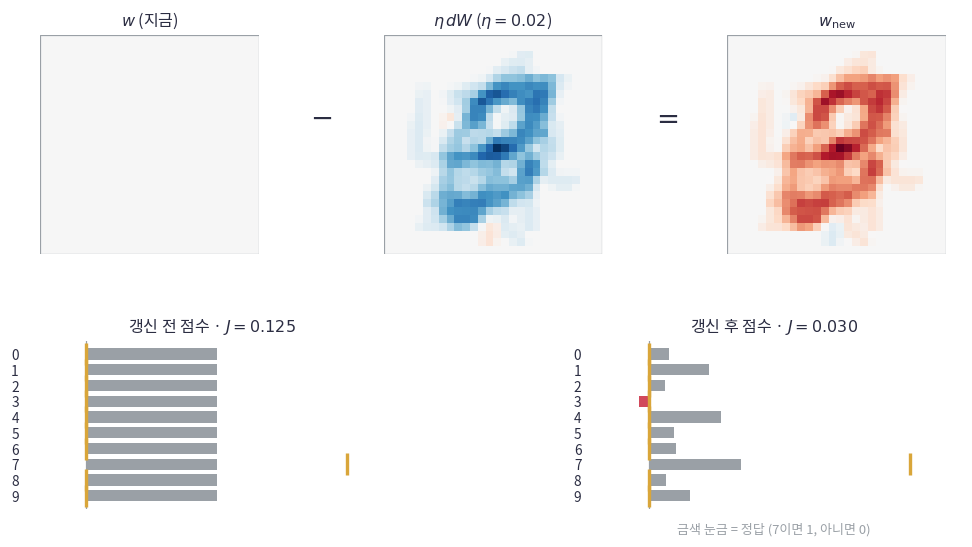

In [24]:
plot_update_step(w_zero.reshape(28, 28), (eta * dW_e).reshape(28, 28), w_new.reshape(28, 28),
                 Z_e.ravel(), Z_after.ravel(), mnist_Te, mnist_labels, loss_before, loss_after, eta)

🔍 **확인** · 위 줄은 $w - \eta\,dW = w_{\mathrm{new}}$를 이미지로 쓴 것입니다. 0이던 가중치에서 기울기를 빼자 아홉 장의 획 자리는 빨강(줄임)이 되었고, 7의 획이 지나는 자리는 덜 줄었습니다.
아래에서 모두 0.5였던 점수가 갈라졌습니다. 아홉 장은 0 쪽으로 크게 내려갔고 7은 가장 높게 남았으며, 손실은 0.125에서 0.030으로 줄었습니다.
한 번에 크게 움직이지 않는 이유는 2절의 근사가 작은 스텝에서만 맞기 때문입니다. `eta`를 0.05로 키우면 손실이 오히려 커집니다(연습에서 확인해 보세요).

In [25]:
# 쓰는 것: X_small, Y_small, W_small, b_small, J_small, dW_small, db_small (4절 작은 예제) · affine_forward (4절) · mse_forward (1절)
learning_rate = 0.1
W_after = W_small - learning_rate * dW_small        # (1, 1): 0 − 0.1·(−4/3) = 0.1333
b_after = b_small - learning_rate * db_small        # (1,): 0 − 0.1·(−1) = 0.1
Z_after, _ = affine_forward(X_small, W_after, b_after)   # 갱신 뒤 예측. 캐시는 안 쓰므로 _
J_after, _ = mse_forward(Z_after, Y_small)               # 갱신 뒤 손실. 잔차도 안 씀
assert J_after < J_small, "한 스텝 뒤 손실이 줄어야 합니다"
print("W", W_small.ravel(), "→", W_after.ravel())
print("b", b_small, "→", b_after)
print(f"손실 {J_small:.6f} → {J_after:.6f}")

W [0.] → [0.1333]
b [0.] → [0.1]
손실 1.833333 → 1.566481


## 🔑 7. 반복하면 실제로 학습되는지 확인합니다

**이 절에서 가져갈 것:** 학습 루프는 네 동작의 반복입니다. 예측 → 손실 → 기울기 → 갱신. 이 네 줄이 모든 신경망 학습의 뼈대입니다.

1. 현재 파라미터로 예측합니다. `Z = X @ W + b`
2. 정답과 비교해 손실을 계산합니다. `J = 0.5 * mean((Z - Y) ** 2)`
3. 손실에서 시작해 기울기를 계산합니다. `dZ = (Z - Y) / M`, `dW = X.T @ dZ`, `db = dZ.sum(0)`
4. 가중치와 편향을 갱신합니다. `W -= eta * dW`, `b -= eta * db`

> **용어** · **스텝(step)**: 위 네 동작을 한 번 수행해 파라미터를 한 번 갱신하는 단위. "100회 갱신"은 100스텝입니다.

먼저 MNIST에서 이 네 줄을 그대로 돌려 봅니다. 가중치를 **0에서** 시작하고, 5,000장으로 100스텝 갱신합니다.


In [26]:
# 쓰는 것: mnist_X, mnist_T (📎 데이터 셀의 학습용 5,000장)
eta_mnist, snapshot_at = 0.03, [0, 1, 5, 20, 100]      # 학습률과 가중치 이미지를 남길 스텝
w_run, b_run = np.zeros((784, 1)), np.zeros(1)          # (784, 1), (1,): 0에서 시작
w_snapshots, loss_snapshots = [], []                    # 기록할 가중치 이미지와 그때의 손실
for step in range(101):
    Z_run = mnist_X @ w_run + b_run                        # 1. 예측 (5000, 1)
    R_run = Z_run - mnist_T                                # 2. 손실: 잔차 (5000, 1)와 절반 MSE
    loss_run = 0.5 * np.mean(R_run ** 2)
    if step in snapshot_at:                                # 갱신 전의 가중치·손실을 기록 (0번째는 초기 상태)
        w_snapshots.append(w_run.reshape(28, 28).copy())   # .copy(): 뒤에서 w_run이 바뀌어도 기록은 그대로
        loss_snapshots.append(loss_run)
    dZ_run = R_run / R_run.size                            # 3. 기울기: dZ = R / M
    w_run -= eta_mnist * mnist_X.T @ dZ_run                # 4. 갱신: w −= η·Xᵀ dZ
    b_run -= eta_mnist * dZ_run.sum(axis=0)                #    b −= η·Σ_n dZ
assert loss_snapshots[-1] < loss_snapshots[0] / 2, "100스텝 뒤 손실이 처음의 절반 아래여야 합니다"
print("손실", np.round(loss_snapshots, 4))

손실 [0.055  0.0465 0.0359 0.0246 0.0198]


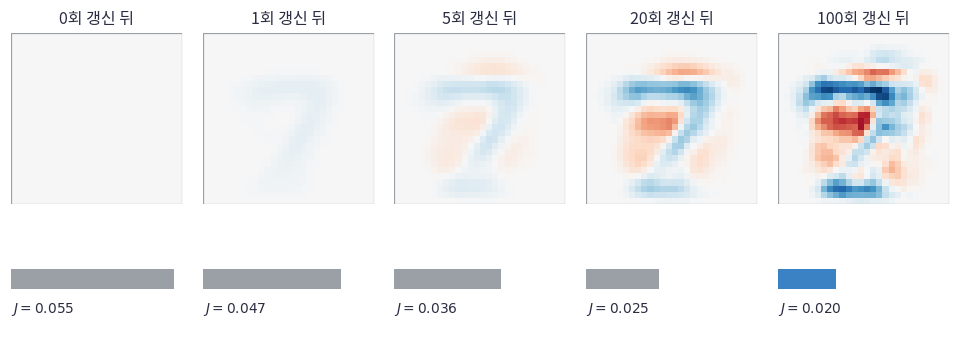

In [27]:
plot_training_images(w_snapshots, loss_snapshots, snapshot_at)

🔍 **확인** · 0회에서는 아무 정보가 없던 가중치가 몇 번의 갱신만으로 "7이 지나가는 자리는 파랑, 다른 숫자가 지나가는 자리는 빨강"인 이미지가 됩니다.
00번에서 평균으로 손으로 만들었던 템플릿과 닮았지만, 이번에는 **손실을 줄이는 과정이 스스로 만든 것**입니다. 손실 막대는 갱신마다 줄어듭니다.

이제 같은 네 줄을 함수로 정리해 과일 데이터에 씁니다. 매 기록의 손실과 파라미터는 같은 시점의 값입니다.
`history["loss"][0]`, `history["W"][0]`, `history["b"][0]`은 각각 갱신 전 손실·가중치·편향입니다.

> **코드**
>
> - `history = {"loss": [], "W": [], "b": []}`: 진행 기록을 담는 사전(dict). 키마다 목록이 하나씩이고, 스텝마다 `append`로 값을 덧붙입니다.
> - `W.copy()`: 배열의 복사본. 목록에 `W`를 그대로 넣으면 다음 갱신 `W -= …`이 기록도 함께 바꾸므로 복사해서 넣습니다.
> - `float(loss)`: NumPy 숫자 하나를 파이썬 숫자로. 기록을 가볍게 하려는 것뿐입니다.

In [28]:
def fit_linear(X, Y, W_start, b_start, learning_rate=0.1, steps=200):
    """선형 회귀를 경사하강으로 steps번 갱신합니다. 스텝마다 위 네 줄: 예측 → 손실 → 기울기 → W −= η·dW, b −= η·db.
    X: (N, D), Y: (N, K), W_start: (D, K), b_start: (K,) → (W, b, history). history의 loss·W·b는 갱신 전 값부터 steps+1개."""
    # 쓰는 것: affine_forward, affine_backward, mse_backward (4절) · mse_forward (1절)
    W, b = W_start.copy(), b_start.copy()                       # 시작값을 바꾸지 않도록 복사
    history = {"loss": [], "W": [], "b": []}
    for step in range(steps + 1):                               # steps+1번 돌며 마지막은 기록만
        prediction, cache = affine_forward(X, W, b)             # 1. 예측
        loss, residual = mse_forward(prediction, Y)             # 2. 손실
        history["loss"].append(float(loss))                     # 같은 시점의 손실·파라미터를 기록
        history["W"].append(W.copy())
        history["b"].append(b.copy())
        if step == steps:                                       # 마지막 기록 뒤에는 갱신하지 않고 끝냅니다
            break
        _, dW, db = affine_backward(mse_backward(residual), cache)   # 3. 기울기. dX는 안 쓰므로 _
        W -= learning_rate * dW                                 # 4. 갱신
        b -= learning_rate * db
    return W, b, history

In [29]:
# 쓰는 것: X_train, Y_train, W_start, b_start (📎 데이터 셀) · loss_start (1절)
W_fit, b_fit, history = fit_linear(X_train, Y_train, W_start, b_start)   # 학습률 0.1로 200스텝
np.testing.assert_allclose(history["loss"][0], loss_start)          # 검산: 기록의 첫 손실 = 1절에서 계산한 시작 손실
print(f"학습 전 손실 {history['loss'][0]:.6f} → 200회 뒤 {history['loss'][-1]:.6f}")
print("학습한 가중치", W_fit.ravel(), "편향", b_fit)
assert history["loss"][-1] < history["loss"][0] / 100, "200스텝 뒤 손실이 처음의 1/100 아래여야 합니다"

학습 전 손실 9.961568 → 200회 뒤 0.008696
학습한 가중치 [1.9842] 편향 [0.6999]


### 🔍 독립적인 해로 검산합니다

> **용어** · **최소제곱(least squares)**: 잔차 제곱합을 가장 작게 만드는 직선을 반복 없이 한 번의 행렬 계산으로 구하는 방법.

이 작은 선형 회귀에는 반복 학습과 다른 풀이도 있습니다.
입력에 1로 된 열을 붙이면 편향도 가중치처럼 함께 다룰 수 있습니다.
최소제곱 해를 계산하는 `np.linalg.lstsq`를 **검산 기준**으로 사용하겠습니다.
이 함수는 손실을 미분해 수백 번 갱신하는 방금 코드와 다른 방법으로 해를 구합니다.

> **코드**
>
> - `np.column_stack([X_train, np.ones(40)])`: 배열들을 열로 나란히 붙입니다. `(40, 1)` 옆에 1로 된 열을 붙여 `(40, 2)`. 두 번째 열의 계수가 곧 편향입니다.
> - `np.linalg.lstsq(A, Y, rcond=None)`: 최소제곱 해와 부가 정보 세 개(잔차·랭크·특이값)를 돌려줍니다. 해만 쓰므로 나머지는 `_`로 버립니다.
> - `np.vstack([W_fit, b_fit[None, :]])`: 배열들을 행으로 쌓습니다. `b_fit[None, :]`는 `(1,)`을 `(1, 1)` 행으로 만든 것이라 `W_fit` `(1, 1)` 아래에 붙어 `(2, 1)`이 됩니다.

In [30]:
# 쓰는 것: X_train, Y_train (📎 데이터 셀) · W_fit, b_fit (앞 학습 셀)
X_with_bias = np.column_stack([X_train, np.ones(len(X_train))])       # (40, 2): [붉기, 1]. 1의 열이 편향 자리
least_squares, _, _, _ = np.linalg.lstsq(X_with_bias, Y_train, rcond=None)   # (2, 1): 최소제곱 해 [w, b]ᵀ
learned_parameters = np.vstack([W_fit, b_fit[None, :]])              # (2, 1): 경사하강 해도 같은 순서로 쌓음
parameter_error = np.max(np.abs(learned_parameters - least_squares))  # 두 해의 가장 큰 차이
np.testing.assert_allclose(learned_parameters, least_squares, rtol=1e-6, atol=1e-7)   # 검산: 경사하강 200스텝 = 최소제곱 해
print("경사하강 해", learned_parameters.ravel())
print("최소제곱 해", least_squares.ravel())
print(f"최대 파라미터 차이 {parameter_error:.2e}")

경사하강 해 [1.9842 0.6999]
최소제곱 해 [1.9842 0.6999]
최대 파라미터 차이 1.20e-09


In [31]:
# 쓰는 것: history (7절 학습 셀). 그림용: 기록해 둔 스텝의 직선
snapshot_steps = [0, 1, 5, 20, 50, 200]                             # 직선을 그릴 스텝
line_x = np.linspace(-2.2, 2.2, 100)[:, None]                       # (100, 1): 1절과 같은 좌표
snapshot_predictions = [line_x @ history["W"][step] + history["b"][step]   # 그 스텝의 W, b로 예측한 직선 (100, 1)
                        for step in snapshot_steps]

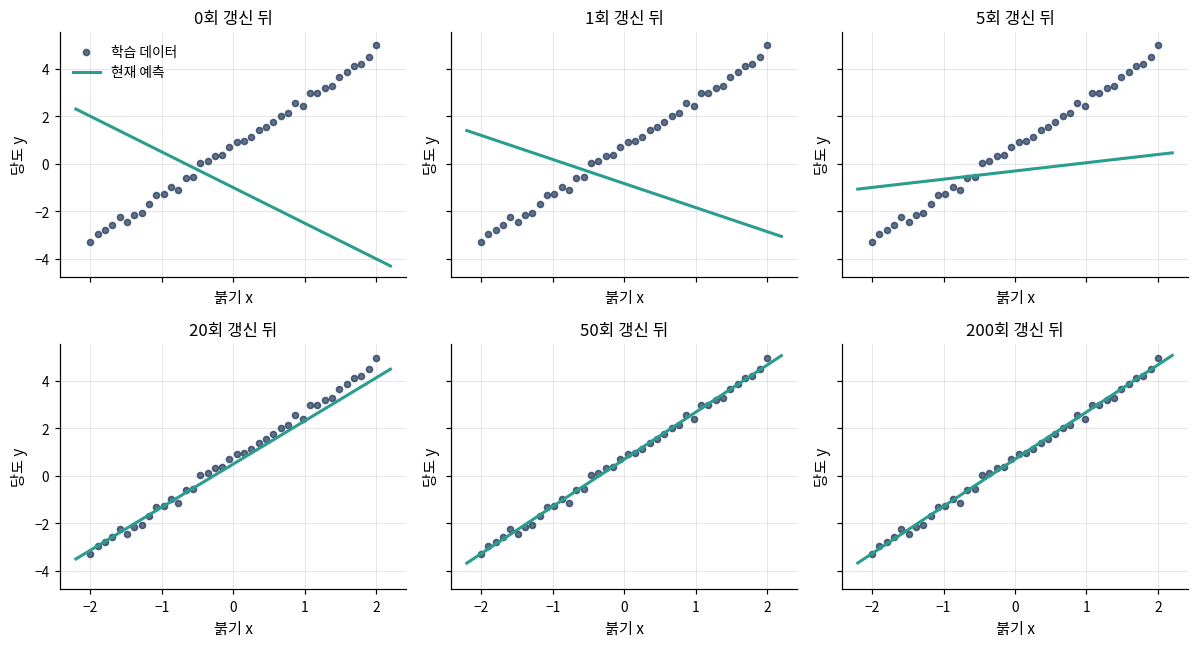

In [32]:
plot_fit_snapshots(X_train, Y_train, line_x, snapshot_predictions, snapshot_steps)

🔍 **확인** · 초기에는 정답과 반대 방향이던 직선이 데이터에 맞추어 움직입니다.
잡음 때문에 손실의 최솟값은 양수이며, 경사하강으로 얻은 파라미터는 같은 데이터의 최소제곱 해에 가까워집니다.
이 비교는 구현한 학습 루프가 이 회귀 문제의 목적을 줄이는지 확인하는 검산입니다.

## 🔍 8. 손실 지형 위에서 갱신을 봅니다

> **용어** · **손실 지형(loss landscape)**: 파라미터를 좌표로, 손실을 높이로 본 지형. 경사하강은 이 지형을 내려가는 것입니다.

가중치와 편향을 좌표로 두고 각 좌표의 손실을 계산하면, 모델이 내려가는 지형을 그릴 수 있습니다.
00번처럼 `meshgrid`로 후보 좌표를 펼칩니다. 이번에는 입력 좌표 대신 가중치와 편향의 후보를 놓습니다.
`ww`, `bb`의 행은 편향 후보, 열은 가중치 후보의 위치입니다.

| 배열 | shape | 각 축의 의미 |
|---|---|---|
| `ww`, `bb` | `(90, 90)` | 편향 후보, 가중치 후보 |
| `X_train[:, 0, None, None]` | `(40, 1, 1)` | 샘플, 편향 자리, 가중치 자리 |
| `ww[None]`, `bb[None]` | `(1, 90, 90)` | 샘플 자리, 편향 후보, 가중치 후보 |
| `grid_predictions` | `(40, 90, 90)` | 샘플, 편향 후보, 가중치 후보 |
| `loss_grid` | `(90, 90)` | 각 파라미터 후보 쌍의 손실 |

📎 인덱싱의 `None`은 길이가 1인 축을 추가합니다. `X_train[:, 0]`으로 유일한 특성을 꺼내고
`None` 두 개로 뒤에 축을 붙이면 `(40, 1, 1)`이 됩니다. `ww[None]`은 앞에 축을 붙입니다.
브로드캐스팅하면 샘플 40개 각각을 후보 파라미터 $90 \times 90$개에 모두 적용할 수 있습니다.
`mean(..., axis=0)`은 샘플 축만 평균내므로 각 후보 쌍의 손실 하나씩이 남습니다.


In [33]:
# 쓰는 것: X_train, Y_train, W_start, b_start (📎 데이터 셀) · history (7절 학습 셀)
ww, bb = np.meshgrid(np.linspace(-2.0, 3.0, 90), np.linspace(-1.5, 2.0, 90))   # (90, 90) 둘: 가중치 후보 × 편향 후보 격자
grid_predictions = X_train[:, 0, None, None] * ww[None] + bb[None]              # (40, 90, 90): 샘플마다 모든 후보 쌍의 예측
loss_grid = 0.5 * np.mean((grid_predictions - Y_train[:, 0, None, None]) ** 2, axis=0)   # (90, 90): 샘플 축만 평균 → 후보 쌍마다 손실
parameter_path = np.array([[W[0, 0], b[0]] for W, b in zip(history["W"], history["b"])])   # (201, 2): 스텝마다 (w, b) 좌표
np.testing.assert_allclose(history["loss"][0],                                    # 검산: 경로 시작점의 손실 =
                          0.5 * np.mean((X_train @ W_start + b_start - Y_train) ** 2))   #   시작 파라미터로 직접 계산한 손실
loss_along_path = np.array(history["loss"][:51])                                # (51,): 처음 50스텝의 손실
print("손실 격자", loss_grid.shape, "· 경로", parameter_path.shape, "· 검산 통과: 경로 시작점의 손실은 시작 파라미터의 손실과 같습니다")

손실 격자 (90, 90) · 경로 (201, 2) · 검산 통과: 경로 시작점의 손실은 시작 파라미터의 손실과 같습니다


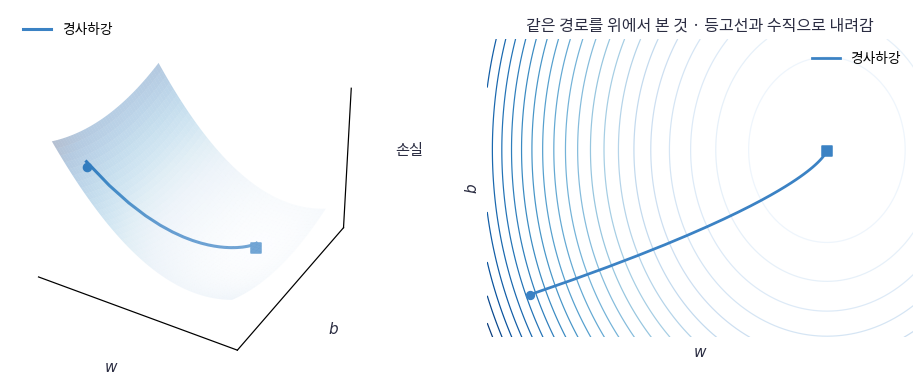

In [34]:
plot_descent_landscape(ww, bb, loss_grid, parameter_path[:51], loss_along_path)

🔍 **확인** · 왼쪽은 손실을 높이로 본 지형이고, 오른쪽은 같은 것을 위에서 본 등고선입니다. 경로는 시작점(점)에서 최솟값(네모)까지 등고선과 수직으로 내려갑니다.
기울기의 반대 방향이 곧 "가장 가파르게 내려가는 방향"이기 때문입니다. 50스텝의 경로만 그렸습니다.

### 🔍 학습률을 바꾸어 결과를 예상합니다

기울기가 정확하더라도 한 번에 너무 멀리 움직이면 손실이 커질 수 있습니다.
같은 시작점에서 작은 학습률, 이번 학습률, 큰 학습률을 비교합니다. 각 실행은 100회 갱신합니다.

In [35]:
# 쓰는 것: X_train, Y_train, W_start, b_start (📎 데이터 셀) · fit_linear (7절)
learning_rate_runs = {}                                     # 학습률 → 손실 기록
for rate in [0.001, 0.1, 1.6]:
    _, _, trial = fit_linear(X_train, Y_train, W_start, b_start, learning_rate=rate, steps=100)   # W, b는 안 쓰므로 _
    learning_rate_runs[f"학습률 {rate:g}"] = trial["loss"]
    print(f"학습률 {rate:g}: {trial['loss'][0]:.6f} → {trial['loss'][-1]:.6f}")
assert learning_rate_runs["학습률 0.1"][-1] < learning_rate_runs["학습률 0.001"][-1], "0.1이 0.001보다 100스텝 뒤 손실이 작아야 합니다"
assert learning_rate_runs["학습률 1.6"][-1] > learning_rate_runs["학습률 1.6"][0], "1.6은 너무 커서 손실이 오히려 커져야 합니다"

학습률 0.001: 9.961568 → 7.618282
학습률 0.1: 9.961568 → 0.008696
학습률 1.6: 9.961568 → 63905625558767566848.000000


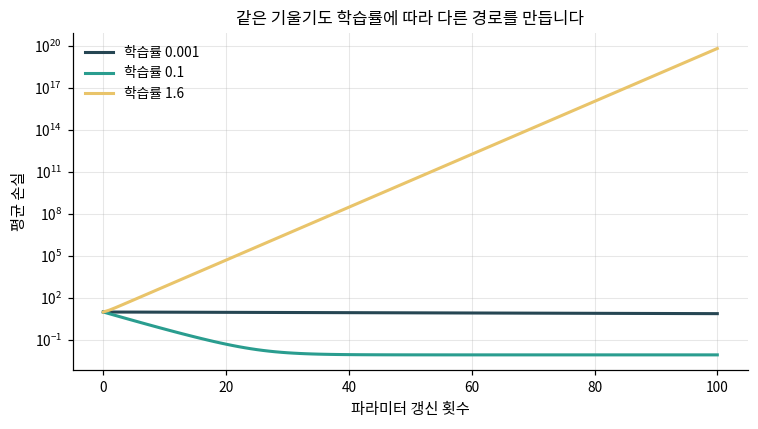

In [36]:
plot_learning_curves(learning_rate_runs)

🔍 **확인** · 기울기 검산과 학습률 실험은 다른 것을 확인합니다.
검산은 **현재 수식의 미분을 정확히 계산했는지**, 학습 실험은 **그 방향으로 정한 크기만큼 움직여 목적이 줄었는지**를 봅니다.
04번에서 Momentum과 Adam을 공부할 때도 기울기 계산은 유지하고 갱신 규칙을 바꾸어 보겠습니다.

## ✏️ 9. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 출력이 2개일 때 평균을 맞추기 (4절)

아래 `(2, 2)` 예측에는 스칼라 오차가 4개 있습니다. 손실이 `0.5 * mean(residual ** 2)`라면 손실의 미분은 각 잔차를 **4로 나눈 값**입니다.

In [37]:
def exercise_mse_backward(residual):
    """연습 A: 절반 MSE의 예측에 대한 미분. residual: (N, K) → dZ: (N, K)."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 절반 MSE의 예측에 대한 미분 dZ (모양 residual과 같음)
    ### 힌트: 평균에 들어간 원소 수 M = residual.size 로 나눕니다.
    raise NotImplementedError
    return dZ

In [38]:
def check_mse_backward(candidate):
    """출력이 2개인 (2, 2) 예제 하나로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mse_forward (1절)
    pred = np.array([[1., 0.], [2., 3.]])            # (2, 2): 샘플 2개 × 출력 2개
    target = np.array([[0., 1.], [0., 1.]])
    loss, residual = mse_forward(pred, target)
    np.testing.assert_allclose(loss, 1.25)                            # 검산: 0.5·(1 + 1 + 4 + 4)/4 = 1.25
    expected = np.array([[0.25, -0.25], [0.5, 0.5]])                 # 잔차 [[1, −1], [2, 2]]를 M = 4로 나눈 것
    np.testing.assert_allclose(candidate(residual), expected)         # 검산: dZ = 잔차 / 4
    print("평균의 분모와 다중 출력 기울기가 손계산과 일치합니다.")

run_check(check_mse_backward, exercise_mse_backward, hint="dZ = residual / residual.size")

☐ exercise_mse_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dZ = residual / residual.size


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dZ = residual / residual.size
```

</details>

### ✏️ 연습 B · 한 스텝 갱신 (6절)

기울기 `dW`, `db`와 학습률을 받아 새 `W`, `b`를 돌려주는 두 줄을 채우세요. 원래 배열은 바꾸지 않습니다.

In [39]:
def exercise_gradient_step(W, b, dW, db, learning_rate):
    """연습 B: 경사하강 한 스텝. W: (D, K), b: (K,), dW·db: 각각 같은 모양, learning_rate: 양수 → (W_new, b_new)."""
    assert W.shape == dW.shape, "dW는 W와 같은 모양이어야 합니다"
    assert b.shape == db.shape, "db는 b와 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 기울기의 반대 방향으로 learning_rate만큼 움직인 W_new, b_new
    ### 힌트: 6절의 W_after, b_after 두 줄입니다.
    raise NotImplementedError
    return W_new, b_new

In [40]:
def check_gradient_step(candidate):
    """4절 작은 예제의 기울기(dW = −4/3, db = −1)로 한 스텝 가서 손실이 주는지 검사합니다."""
    # 쓰는 것: X_small, Y_small, J_small (4절 작은 예제) · affine_forward (4절) · mse_forward (1절)
    W0, b0 = np.array([[0.0]]), np.array([0.0])
    W1, b1 = candidate(W0, b0, np.array([[-4 / 3]]), np.array([-1.0]), 0.1)
    np.testing.assert_allclose(W1, [[0.4 / 3]])                      # 검산: 0 − 0.1·(−4/3)
    np.testing.assert_allclose(b1, [0.1])                            # 검산: 0 − 0.1·(−1)
    np.testing.assert_array_equal(W0, [[0.0]])                       # 검산: 원래 배열은 그대로
    Z1, _ = affine_forward(X_small, W1, b1)
    assert mse_forward(Z1, Y_small)[0] < J_small, "한 스텝 뒤 손실이 4절의 J_small보다 작아야 합니다"
    print("한 스텝 갱신: 4절 예제의 손실이 줄었습니다.")

run_check(check_gradient_step, exercise_gradient_step, hint="W_new = W - learning_rate * dW (b도 같은 식)")

☐ exercise_gradient_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: W_new = W - learning_rate * dW (b도 같은 식)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
W_new = W - learning_rate * dW
b_new = b - learning_rate * db
```

</details>

### ✏️ 연습 C · 선형층의 backward (4절)

상류 기울기 `dZ`와 캐시 `X`, `W`에서 `dW`, `db`를 만드는 두 줄을 채우세요. `dX`는 미리 써 두었습니다.

In [41]:
def exercise_affine_backward(dZ, X, W):
    """연습 C: 선형층 backward. dZ: (N, K), X: (N, D), W: (D, K) → (dX: (N, D), dW: (D, K), db: (K,))."""
    dX = dZ @ W.T                # (N, D): 미리 써 둔 줄
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dW (모양 W와 같음)와 db (모양 (K,))
    ### 힌트: dW는 샘플 축을 곱해 더하는 X.T와의 행렬곱, db는 샘플 축(axis=0)의 합입니다.
    raise NotImplementedError
    return dX, dW, db

In [42]:
def check_affine_backward(candidate):
    """4절 작은 예제의 손계산과, 무작위 (4, 3)·(3, 2) 입력에서 본문 affine_backward와 비교합니다."""
    # 쓰는 것: X_small, W_small, affine_backward (4절)
    dZ = np.array([[1 / 3], [-1 / 3], [-1.0]])                      # (3, 1): 4절 작은 예제의 dZ = 잔차 [1, −1, −3] / 3
    dX, dW, db = candidate(dZ, X_small, W_small)
    np.testing.assert_allclose(dW, [[-4 / 3]])                       # 검산: 4절 손계산 dW
    np.testing.assert_allclose(db, [-1.0])                           # 검산: 4절 손계산 db
    np.testing.assert_allclose(dX, dZ @ W_small.T)                   # 검산: 미리 써 둔 dX 줄
    rng_c = np.random.default_rng(1)
    Xc, Wc, dZc = rng_c.normal(size=(4, 3)), rng_c.normal(size=(3, 2)), rng_c.normal(size=(4, 2))   # 출력이 2개인 무작위 예제
    _, dWc, dbc = candidate(dZc, Xc, Wc)
    np.testing.assert_allclose(dWc, affine_backward(dZc, (Xc, Wc))[1])   # 검산: 본문 함수의 dW와 같음
    np.testing.assert_allclose(dbc, dZc.sum(axis=0))                     # 검산: db = 샘플 축의 합
    print("선형층 backward: 손계산과 본문 함수 모두와 일치합니다.")

run_check(check_affine_backward, exercise_affine_backward, hint="dW = X.T @ dZ, db = dZ.sum(axis=0)")

☐ exercise_affine_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dW = X.T @ dZ, db = dZ.sum(axis=0)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dW = X.T @ dZ
db = dZ.sum(axis=0)
```

</details>

### 🔍 완성 예제 · 두 출력을 동시에 학습하기

같은 입력에서 $y_0=2x+0.7$, $y_1=-x+0.2$를 동시에 예측합니다. $W$는 `(1, 2)`, $b$는 `(2,)`가 되고 기존 forward·backward·학습 함수가 그대로 동작합니다.
계수나 출력 개수를 바꾸어 실행해 보세요.

In [43]:
# 쓰는 것: X_train (📎 데이터 셀) · fit_linear (7절)
Y_two = np.column_stack([2.0 * X_train[:, 0] + 0.7, -X_train[:, 0] + 0.2])   # (40, 2): 정답 두 열. 잡음 없음
W_two, b_two, history_two = fit_linear(
    X_train, Y_two, np.zeros((1, 2)), np.zeros(2), learning_rate=0.2, steps=200,   # W: (1, 2), b: (2,)를 0에서 시작
)
np.testing.assert_allclose(W_two, [[2., -1.]], atol=1e-7)     # 검산: 열마다 기울기 2, −1을 찾음
np.testing.assert_allclose(b_two, [0.7, 0.2], atol=1e-7)      # 검산: 편향 0.7, 0.2
print("두 출력의 가중치", W_two, "편향", b_two)
print(f"최종 손실 {history_two['loss'][-1]:.2e}")

두 출력의 가중치 [[ 2. -1.]] 편향 [0.7 0.2]
최종 손실 6.60e-20


### ✏️ 준비도 질문 · 설명을 가리고 연결해 보기

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

1. $J=\frac1{2M}\sum_j(\hat y_j-y_j)^2$에서 예측에 대한 미분을 다시 유도할 수 있나요?
2. `dW = X.T @ dZ`를 인덱스와 합으로 풀어 쓸 수 있나요? MNIST에서 이 값이 왜 이미지 모양인지 말할 수 있나요?
3. 편향 기울기를 구할 때 샘플들의 기여를 더하는 이유를 설명할 수 있나요?
4. forward·손실·backward·update 네 부분을 직접 다시 작성할 수 있나요?
5. 손실이 커졌을 때 미분 오류와 학습률 문제를 각각 어떤 방법으로 점검할지 말할 수 있나요?

막힌 질문에 해당하는 절로 돌아가 작은 숫자로 한 번 더 계산합니다.

**다음 단원: 확률과 손실.** 확률·밀도·기댓값·우도를 코드로 확인하고,
가우스 오차에서 MSE, 범주형 확률에서 교차엔트로피가 나오는 과정을 연결합니다.

다음: [02 · 확률에서 손실 만들기](02_probability_and_losses.ipynb)